In [13]:
import pandas as pd
import zipfile 
zip_path = r"K:\RESEARCH PROJECTS\Prof. Gaurav Arora\price data\csv.zip"
with zipfile.ZipFile(zip_path,'r') as z:
    first_csv= [f for f in z.namelist() if f.endswith('.csv')][0]
    with z.open(first_csv) as f:
        columns= pd.read_csv(f, nrows=0).columns.tolist()
for col in columns:
    print(f"{col}")
        
    

State
District
Market
Commodity
Variety
Grade
Arrival_Date
Min_Price
Max_Price
Modal_Price
Commodity_Code


In [ ]:

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('2022.csv') as f:
        df= pd.read_csv(f, usecols= ['State', 'Commodity', 'Commodity_Code', 'Variety'])
df['State']= df['State'].str.title().str.strip()
df['Variety']= df['Variety'].str.title().str.strip()
df['Commodity'] = df['Commodity'].str.title().str.strip()

is_ap= df['State']== 'Andhra Pradesh'
is_tomato= df['Commodity']== 'Tomato'
ap_tomatoes= df[is_ap&is_tomato]
commodity_table= ap_tomatoes[['Commodity_Code', 'Variety']].drop_duplicates()
print(commodity_table)

In [ ]:
import zipfile 
zip_path = r"K:\RESEARCH PROJECTS\Prof. Gaurav Arora\price data\csv.zip"
with zipfile.ZipFile(zip_path,'r') as z:
    all_csvs = [f for f in z.namelist() if f.endswith('.csv')]
    
    for file_name in all_csvs:
        
        with z.open(file_name) as f:
            df = pd.read_csv(f, usecols=['State', 'Commodity', 'Variety'])
            
        df['State'] = df['State'].str.title().str.strip()
        df['Commodity'] = df['Commodity'].str.title().str.strip()
        df['Variety'] = df['Variety'].str.title().str.strip()
        
        is_ap = df['State'] == 'Andhra Pradesh'
        is_tomato = df['Commodity'] == 'Tomato'
        ap_tomatoes = df[is_ap & is_tomato]
        
        varieties_this_year = ap_tomatoes['Variety'].unique()
        
        has_local = 'Local' in varieties_this_year
        has_hybrid = 'Hybrid' in varieties_this_year
        year = file_name.replace('.csv', '') 
        
        if has_local and has_hybrid:
            print(f"Year {year}: YES - Both Local and Hybrid were present.")
        else:
            print(f"Year {year}: NO  - (Local present: {has_local} | Hybrid present: {has_hybrid})")

Year 2021: NO  - (Local present: True | Hybrid present: False)
Year 2013: YES - Both Local and Hybrid were present.
Year 2025: YES - Both Local and Hybrid were present.
Year 2017: YES - Both Local and Hybrid were present.
Year 2014: YES - Both Local and Hybrid were present.
Year 2006: YES - Both Local and Hybrid were present.
Year 2011: YES - Both Local and Hybrid were present.
Year 2023: YES - Both Local and Hybrid were present.
Year 2007: YES - Both Local and Hybrid were present.
Year 2002: NO  - (Local present: False | Hybrid present: False)
Year 2004: NO  - (Local present: True | Hybrid present: False)
Year 2008: YES - Both Local and Hybrid were present.
Year 2016: YES - Both Local and Hybrid were present.
Year 2019: YES - Both Local and Hybrid were present.
Year 2010: YES - Both Local and Hybrid were present.
Year 2026: YES - Both Local and Hybrid were present.
Year 2024: YES - Both Local and Hybrid were present.
Year 2001: NO  - (Local present: False | Hybrid present: False)
Year

In [2]:
import pandas as pd
import zipfile
zip_path = r"K:\RESEARCH PROJECTS\Prof. Gaurav Arora\price data\csv.zip"

data_pieces = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for year in range(2015, 2026): 
        file_name = f"{year}.csv"
        if file_name in z.namelist():
            with z.open(file_name) as f:
                df_year= pd.read_csv(f,usecols=['State', 'Commodity', 'Arrival_Date', 'Modal_Price', 'Variety'])
                data_pieces.append(df_year)                    
                                 
df = pd.concat(data_pieces, ignore_index=True)

df['State'] = df['State'].str.title().str.strip()
df['Commodity'] = df['Commodity'].str.title().str.strip()
df['Variety']= df['Variety'].str.title().str.strip()


is_ap = df['State'] == 'Andhra Pradesh'
is_tomato = df['Commodity'] == 'Tomato'
is_variety= df['Variety']== 'Local'

df_ap = df[is_ap & is_tomato & is_variety].copy()

df_ap['Arrival_Date'] = pd.to_datetime(df_ap['Arrival_Date'])


df_daily = df_ap.groupby('Arrival_Date')['Modal_Price'].mean().reset_index()
df_daily = df_daily.sort_values('Arrival_Date')
df_daily = df_daily.set_index('Arrival_Date')
df_daily = df_daily.asfreq('D')
df_daily['Modal_Price'] = df_daily['Modal_Price'].ffill(limit=2)
df_daily['Modal_Price'] = df_daily['Modal_Price'].interpolate(method='linear')

print(df_daily.head(10))
print(len(df_daily))

C:\Users\Kanishk Rathore\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


              Modal_Price
Arrival_Date             
2015-01-01     660.000000
2015-01-02     700.000000
2015-01-03     950.000000
2015-01-04     700.000000
2015-01-05     714.285714
2015-01-06     700.000000
2015-01-07     728.571429
2015-01-08     642.857143
2015-01-09     621.428571
2015-01-10     564.285714
4016


In [4]:
from statsmodels.tsa.stattools import adfuller, kpss
prices = df_daily['Modal_Price'].dropna()
print("ADF Test")

adf_result = adfuller(prices)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Test
ADF Statistic: -7.6187
p-value:       0.0000
Critical Values:
   1%: -3.4320
   5%: -2.8623
   10%: -2.5672


C:\Users\Kanishk Rathore\AppData\Local\Temp\ipykernel_31612\3962947735.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(prices)


In [5]:
import numpy as np
import statsmodels.api as sm
from scipy.signal import periodogram
import matplotlib.pyplot as plt

KPSS Test
KPSS Statistic: 1.3807
p-value:        0.0100
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390


C:\Users\Kanishk Rathore\AppData\Local\Temp\ipykernel_31612\1380625284.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(prices, regression='c', nlags='auto')
C:\Users\Kanishk Rathore\AppData\Local\Temp\ipykernel_31612\1380625284.py:3: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_result = kpss(prices, regression='c', nlags='auto')


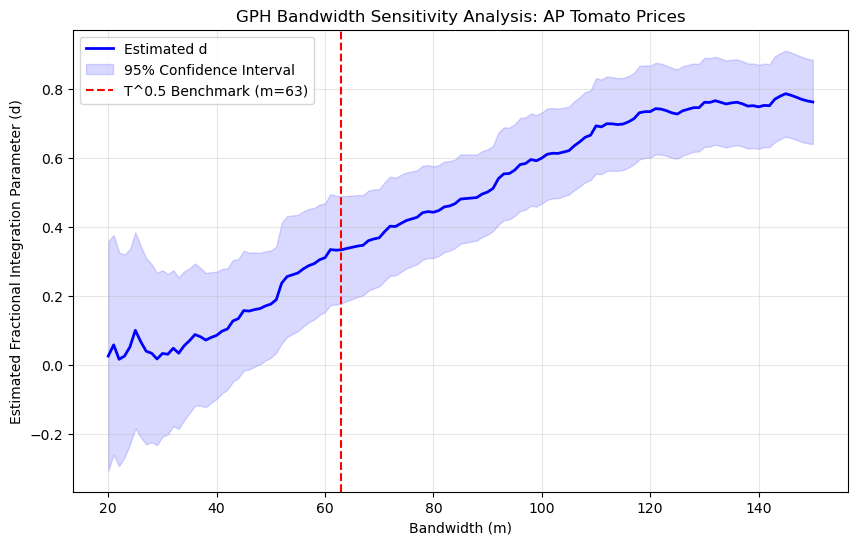

In [7]:
import numpy as np
import statsmodels.api as sm
from scipy.signal import periodogram
import matplotlib.pyplot as plt

def calculate_gph_for_m(series, m):
    y = series.dropna().values
    frequencies, spectrum = periodogram(y)
    
    # Slice the frequencies based on the specific 'm' we injected
    local_freqs = frequencies[1:m+1]
    local_spectrum = spectrum[1:m+1]
    
    X = -2 * np.log(local_freqs)
    Y = np.log(local_spectrum)
    
    X_with_constant = sm.add_constant(X)
    model = sm.OLS(Y, X_with_constant).fit()
    
    # Return both the estimate and the 95% confidence intervals
    d = model.params[1]
    conf_int = model.conf_int(alpha=0.05)[1] 
    return d, conf_int[0], conf_int[1]


T = len(df_daily['Modal_Price'].dropna())
default_m = int(T ** 0.5)

m_values = list(range(20, 151))
d_estimates = []
lower_bounds = []
upper_bounds = []


for m in m_values:
    d, lower, upper = calculate_gph_for_m(df_daily['Modal_Price'], m)
    d_estimates.append(d)
    lower_bounds.append(lower)
    upper_bounds.append(upper)
plt.figure(figsize=(10, 6))
plt.plot(m_values, d_estimates, color='blue', linewidth=2, label='Estimated d')
plt.fill_between(m_values, lower_bounds, upper_bounds, color='blue', alpha=0.15, label='95% Confidence Interval')
plt.axvline(x=default_m, color='red', linestyle='--', label=f'T^0.5 Benchmark (m={default_m})')

plt.title('GPH Bandwidth Sensitivity Analysis: AP Tomato Prices')
plt.xlabel('Bandwidth (m)')
plt.ylabel('Estimated Fractional Integration Parameter (d)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.signal import periodogram

def calculate_local_whittle(series, m):
    y = series.dropna().values
    y = y - np.mean(y) 
    
    frequencies, I = periodogram(y)
    
    lam = frequencies[1:m+1] * (2 * np.pi)
    I_local = I[1:m+1]
    
   
    def whittle_objective(d, lam, I_local):
        G = np.mean((lam ** (2 * d)) * I_local)
        R_d = np.log(G) - 2 * d * np.mean(np.log(lam))
        return R_d
        
    
    result = minimize_scalar(
        whittle_objective, 
        bounds=(-0.5, 0.5), 
        args=(lam, I_local), 
        method='bounded'
    )
    
    d_est = result.x
    std_error = 1.0 / (2 * np.sqrt(m))
    t_stat = d_est / std_error
    
    
    print(f"Bandwidth (m):      {m}")
    print(f"Estimated d:        {d_est:.4f}")
    print(f"Standard Error:     {std_error:.4f}")
    print(f"T-statistic:        {t_stat:.4f}")
    
    return d_est

optimal_m = 63
d_whittle = calculate_local_whittle(df_daily['Modal_Price'], optimal_m)

Bandwidth (m):      63
Estimated d:        0.4067
Standard Error:     0.0630
T-statistic:        6.4565
